### Current Scale:

-   SWC_50
-   Station 3
-   Remove long/lat


In [32]:
import os
import math
import argparse
import warnings
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler

import importlib
import dataloader
from dataloader import get_windows_data, MaskedDataset




device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Apply Feature Engineering to Data

-   Adds features for time to capture the cyclical nature of our data
-   Adds features for precipitation to capture potential causes to moisture change (can be updated based on other projects' findings)
-   Modifies wind features to learnable x/y velocities

Potential Additions:

-   Make sure precipitation features are NaN'd out if original feature is missing
-   Concat dependent features first


## Data Pre-processing


## Window Creation

Todo:

Create 3 different types of window/label schemes

-   X: Artifically masked window; y: Original window
-   X: Past Window; y: Present Values
-   X: Past and Future window; y: Present Values


Task: Create exception handlers for other data preprocessing functions


## Training / Testing Split


Make the dataloader be (original, masked, mask)


Data Preprocessing:

-   For 'HoursSinceRain'
    -   Identify Rain Events (ppt > 0)
    -   We should make it so it is hours since last KNOWN rain (If ppt has nan, HoursSinceRain will be nan until there is ppt again)
        but honestly ppt is 0 most the time, so if this method produces too many nan values, just scrap it
-   For Ppt Sums
    -   the sum should be nan if any value in its window is nan (fine tuning)


### Masking

Potential Additions:

-   Mask out dependent features from the original features (Ex: if 'Ppt' is masked out, mask out 'Ppt_3h_sum')
-   Add arguments to make combination of masks more specific rather than random (make it so we have a hyperparameter (maybe dictionary) with probabilities of masking types)
-   If combination random, make it so each window has a different distribution of the type of masking instead of a batch of windows having the same distribution


In [8]:
ORIGINAL_FEATURE_NUM = 20

def create_random_mask(data, mask_amt = 0.1):
    
    num_windows, window_size, num_features = data.shape
    vals_per_window = window_size * ORIGINAL_FEATURE_NUM
    # print(vals_per_window)
    num_vals_mask = max(1, int(vals_per_window * mask_amt))
    
    # Produce a random distribution in the shape of (num_windows, values per window)
    rand = torch.rand((num_windows, vals_per_window))
    
    # Select the smallest 'num_vals_mask' random values and grabs the largest one as the threshold
    thresholds = torch.topk(rand, num_vals_mask, largest=False, dim=1).values[:, -1].unsqueeze(1)
    
    # Makes a flat mask where True are the 'num_vals_mask' random values that are below the threshold
    mask_flat = rand <= thresholds
    
    # Reshape mask to original data shape
    mask = torch.zeros_like(data, dtype=torch.bool)
    
    actual_mask = mask_flat.view(num_windows, window_size, ORIGINAL_FEATURE_NUM)
    
    mask[:,:window_size,:ORIGINAL_FEATURE_NUM] = actual_mask
    
    return mask.bool()

def create_block_mask(data, mask_amt = 0.1, max_block_size = 0):
    
    num_windows, row_range, _ = data.shape
    col_range = ORIGINAL_FEATURE_NUM
    vals_per_window = row_range * col_range
    num_vals_mask = max(1, int(vals_per_window * mask_amt))
    
    mask = torch.zeros_like(data, dtype=torch.bool)
    
    for i in range(num_windows):
        masked_vals = 0
        while num_vals_mask > masked_vals:
            remaining_vals = num_vals_mask - masked_vals
            
            max_possible_block = min(remaining_vals, row_range * col_range)
            if max_block_size > 0:
                max_possible_block = min(max_possible_block, max_block_size)
            
            block_width = torch.randint(1, min(max_possible_block, row_range) + 1, (1,)).item()
            block_len = torch.randint(1, min(max_possible_block // block_width, col_range) + 1, (1,)).item()
                
            r = torch.randint(0, row_range - block_width + 1, (1,)).item()
            c = torch.randint(0, col_range - block_len + 1, (1,)).item()
            
            masked_before = mask[i, r:r+block_width, c:c+block_len].sum().item()
            
            mask[i, r:r+block_width, c:c+block_len] = True       
            
            newly_masked = block_width * block_len - masked_before
            masked_vals += newly_masked

    return mask.bool()

def create_row_mask(data, mask_amt = 0.1):
    
    num_windows, row_range, _ = data.shape
    col_range = ORIGINAL_FEATURE_NUM
    vals_per_window = row_range * col_range
    num_vals_mask = max(1, int(vals_per_window * mask_amt))

    mask = torch.zeros_like(data, dtype=torch.bool)
    
    for i in range(num_windows):
        masked_vals = 0
        while num_vals_mask > masked_vals:
            remaining_vals = num_vals_mask - masked_vals
            
            max_possible_block = min(remaining_vals, row_range * col_range)
            
            block_len = col_range
            block_width = torch.randint(1, min(math.ceil(max_possible_block / block_len), row_range) + 1, (1,)).item()
            
            r = torch.randint(0, row_range - block_width + 1, (1,)).item()

            masked_before = mask[i, r:r+block_width,:col_range].sum().item()

            mask[i, r: r + block_width,:col_range] = True   
            
            newly_masked = block_width * block_len - masked_before
            masked_vals += newly_masked
        
        
    return mask.bool()

def create_col_mask(data, mask_amt = 0.1):
  
    num_windows, row_range, _ = data.shape
    col_range = ORIGINAL_FEATURE_NUM
    vals_per_window = row_range * col_range
    num_vals_mask = max(1, int(vals_per_window * mask_amt))
    
    mask = torch.zeros_like(data, dtype=torch.bool)
    
    for i in range(num_windows):
        masked_vals = 0
        while num_vals_mask > masked_vals:
            remaining_vals = num_vals_mask - masked_vals
            
            max_possible_block = min(remaining_vals, row_range * col_range)
            
            block_width = row_range
            block_len = torch.randint(1, min(math.ceil(max_possible_block / block_width), col_range) + 1, (1,)).item()
            
            c = torch.randint(0, col_range - block_len + 1, (1,)).item()

            masked_before = mask[i,:, c:c+block_len].sum().item()
            
            mask[i,:, c:c+block_len] = True   
            
            newly_masked = block_width * block_len - masked_before
            masked_vals += newly_masked

    return mask.bool()

def apply_mask(data, tot_mask_amt = 0.5):
    mask_amts = np.random.dirichlet(np.ones(4)) * tot_mask_amt
    
    rand_mask = create_random_mask(data, mask_amts[0])
    block_mask = create_block_mask(data, mask_amts[1])
    row_mask = create_row_mask(data, mask_amts[2])
    col_mask = create_col_mask(data, mask_amts[3])
    
    final_mask = rand_mask | block_mask | row_mask | col_mask
    
    return final_mask

FEATURE_LIST = [
    "Ppt", "Ppt_3h_sum", "Ppt_24h_sum", "Ppt_RainFlag", "HoursSinceRain",
    # ... add more features here in order ...
]

DEPENDENT_FEATURES = {
    "Ppt": ["Ppt_3h_sum", "Ppt_24h_sum", "Ppt_RainFlag", "HoursSinceRain"]
}
def apply_dependent_masking(mask, feature_list, dependent_features):
    """
    Enforces masking dependencies:
    If a base feature is masked at any timestep, its dependent features are also masked.
    """
    for base_feat, dependents in dependent_features.items():
        if base_feat not in feature_list:
            continue
        base_idx = feature_list.index(base_feat)
        base_mask = mask[:, :, base_idx]

        for dep_feat in dependents:
            if dep_feat in feature_list:
                dep_idx = feature_list.index(dep_feat)
                mask[:, :, dep_idx] |= base_mask

    return mask

mask_type_probs = {
    'random': 0.25,
    'block': 0.25,
    'row': 0.25,
    'col': 0.25
}

def create_per_window_mask(window, tot_mask_amt, mask_type_probs):
    """
    Creates a composite mask for a single window using a randomized distribution
    of mask types based on mask_type_probs.
    """
    alpha = np.array([mask_type_probs[k] for k in ['random', 'block', 'row', 'col']])
    mask_amts = np.random.dirichlet(alpha) * tot_mask_amt

    rand_mask = create_random_mask(window, mask_amts[0])
    block_mask = create_block_mask(window, mask_amts[1])
    row_mask = create_row_mask(window, mask_amts[2])
    col_mask = create_col_mask(window, mask_amts[3])

    combined_mask = rand_mask | block_mask | row_mask | col_mask
    return combined_mask




## Model

-   Update architecture:

    -   Right now the model poorly uses BiLSTM and Convolutional blocks

    Final Goals:

    -   BRITS
    -   CATSI
    -   A masked autoencoder transformer architecture (MTSIT)


In [27]:
#Input should be shape (batch, time, features)

class MLP_MAE(nn.Module):
    def __init__(self, time_len, feat_dim, d_model, num_layers, dropout=0.1):
        super(MLP_MAE, self).__init__()
        
        self.d_model = d_model
    
        self.proj_inp = nn.Linear(feat_dim, d_model)
        
        self.pos_emb = nn.Parameter(torch.randn(1, time_len, d_model))
        
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=d_model // 2,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.ff_block = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(d_model, feat_dim)
        )
    
    def forward(self, masked_in):
        inp = masked_in.clone()
        B, T, D = inp.shape
        
        inp = self.proj_inp(inp) * math.sqrt(self.d_model)
        inp = inp + self.pos_emb

        # inp = self.ff_block(inp)
    
 
        conv_in = inp.permute(0, 2, 1) 
        conv_out = self.conv_blocks(conv_in)
        conv_out = conv_out.permute(0, 2, 1) 
        
        lstm_out, _ = self.lstm(conv_out)
    
        out = self.decoder(lstm_out)
        
        return out
        

In [28]:
def masked_mse_loss(pred, target, mask):
    loss = (pred - target) ** 2
    masked_loss = loss[mask]
    if masked_loss.numel() == 0:
        return torch.tensor(0.0, device=pred.device)
    return masked_loss.mean()

def visualize_progress(metrics, display_handle=None, display_id='visualization'):
    max_cols = 4
    n_plots = len(metrics)
    n_cols = min(n_plots, max_cols)
    n_rows = math.ceil(n_plots / n_cols)
    figsize = (15, 3 * n_rows)
    fig = plt.figure(num=200, figsize=figsize)
    plt.clf()  # Clear the current figure
    for idx, name in enumerate(list(metrics.keys())):
        if name != 'images':
            plt.subplot(n_rows, n_cols, idx + 1)
            if len(metrics[name]) > 0:  # Only plot if we have data
                plt.plot(metrics[name], label=name)
            plt.title(name)
            plt.xlabel('Iteration')
            plt.ylabel('Value')
            plt.grid(True)
    
    images = metrics.get('images', None)
    if images is not None:
        ax = plt.subplot(n_rows, n_cols, n_plots)
        ax.set_title('Visualization')
        plt.imshow(images)
        plt.axis('off')
    
    plt.tight_layout()
    if display_handle is None:
        display_handle = display.display(display.HTML(''), display_id=display_id)
    display_handle.update(fig)
    plt.close()
    return display_handle

### Train/Eval Loop

-   Evaluation is hard-coded right now. Create a better looking visual


In [29]:
def load_data (windows_data, batch_size = 32, val_split = 0.1, mask_amt = 0.5):

    dataset = MaskedDataset(windows_data, mask_amt)
    val_size = int(val_split * len(dataset))
    train_size = len(dataset) - val_size
    
    train_dataset, val_dataset = random_split(
        dataset, [train_size, val_size]
    )
    
    pin_memory = torch.cuda.is_available()
    
    train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=8,
            pin_memory=pin_memory
        )
        
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=8,
        pin_memory=pin_memory
    )
    
    print(f"Dataset loaded with {len(dataset)} windows")
    print(f"Training samples: {train_size}, Validation samples: {val_size}")
    
    return train_loader, val_loader

In [ ]:
def evaluate_model(model, test_loader, verbose=True):
            

In [40]:
def train_mae(mlp_mae, train_loader, val_loader, num_epochs=100,
                    device="cpu", learning_rate=0.001):
    
    optimizer = torch.optim.Adam(mlp_mae.parameters(), learning_rate)
    
    mlp_mae = mlp_mae.to(device)
    
    visual_metric = {'train_loss': [],
                     'val_loss': []}
    display_handle = None
    
    print("Starting Training...")
    for epoch in range(num_epochs):
        mlp_mae.train()
        
        epoch_losses = []
        
        for i, batch in enumerate(tqdm(train_loader)):
            # print(type(window_batch), len(window_batch))
            # print(type(window_batch[0]))
            # data = batch['masked']
            # data = window_batch_in.to(device)
            # mask = apply_mask(data, 0.5)
            original_data = batch['original'].to(device)
            masked_data = batch['masked'].to(device)
            mask = batch['mask'].to(device)
            
            output = mlp_mae(masked_data)
            
            loss = masked_mse_loss(output, original_data, mask)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
            
            # Visualization
            visual_metric['train_loss'].append(loss.item())
            
            if i % 100 == 0:
                display_handle = visualize_progress(visual_metric, 
                                                   display_handle, 
                                                   display_id='Training')

        # Calculate average training loss for the epoch
        avg_train_loss = sum(epoch_losses) / len(epoch_losses)
        
        # Validation phase
        mlp_mae.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                original_data = batch['original'].to(device)
                masked_data = batch['masked'].to(device)
                mask = batch['mask'].to(device)
                
                output = mlp_mae(masked_data)
                loss = masked_mse_loss(output, original_data, mask)
                val_losses.append(loss.item())
        
        avg_val_loss = sum(val_losses) / len(val_losses)
        visual_metric['val_loss'].append(avg_val_loss)
    
        """
        
        THIS SHOULD BE WHERE AN EVALUATION FUNCTION SHOULD GO (REPLACE EVERYTHING IN THE CONDITIONAL BELOW)
        
        """
        if epoch % 10 == 0:
            with torch.no_grad():
                mlp_mae.eval()
                test_window = windows_data[5].unsqueeze(0).to(device)
                mask = torch.zeros_like(test_window, dtype=torch.bool).to(device)
                mask[:, :14, 10:16] = True  # Mask first 14 features for time steps 10-16
                
                # Transform input data to original scale
                input_np = test_window.detach().cpu().numpy()
                input_flat = input_np.reshape(-1, 24)
                input_scaled_part = input_flat[:, features_indicies]
                input_unscaled_part = scaler.inverse_transform(input_scaled_part)
                input_flat[:, features_indicies] = input_unscaled_part
                input_original_scale = input_flat.reshape(1, 24, 24)
                
                # Get predictions
                output = mlp_mae(test_window, mask)
                output_np = output.detach().cpu().numpy()
                output_flat = output_np.reshape(-1, 24)
                scaled_part = output_flat[:, features_indicies]
                unscaled_part = scaler.inverse_transform(scaled_part)
                output_flat[:, features_indicies] = unscaled_part
                output_original_scale = output_flat.reshape(1, 24, 24)
                
                # Create subplots for each masked feature
                num_features = 14
                fig, axes = plt.subplots(num_features, 1, figsize=(12, 4*num_features))
                fig.suptitle('Original vs Predicted Values for Masked Features', fontsize=16)
                
                for i in range(num_features):
                    feature_name = features[i]
                    ax = axes[i]
                    
                    # Get original and predicted values
                    original_values = input_original_scale[0, :, i]
                    predicted_values = output_original_scale[0, :, i]
                    
                    # Plot original values
                    ax.plot(original_values, label='Original', marker='o', color='blue', markersize=4)
                    
                    # Plot predicted values only in the masked region
                    masked_indices = range(10, 16)
                    ax.plot(masked_indices, predicted_values[masked_indices], 
                            label='Predicted', marker='x', color='red', linestyle='--', markersize=4)
                    
                    # Add gray background for masked region
                    ax.axvspan(9.5, 15.5, alpha=0.2, color='gray', label='Masked Region')
                    
                    ax.set_title(f'{feature_name}')
                    ax.set_xlabel('Time Steps')
                    ax.set_ylabel('Value')
                    ax.legend()
                    ax.grid(True)
                
                plt.tight_layout()
                plt.show()
        


In [ ]:
# import importlib
# import dataloader
# from dataloader import get_windows_data, MaskedDataset

# importlib.reload(dataloader)

batch_size = 32

windows_data, scalers, features = get_windows_data([3])
window_size, num_features = windows_data[0].shape

train_loader, val_loader = load_data(windows_data)

# mlp_mae = MLP_MAE(window_size, num_features, 64, 3)

# train_mae(mlp_mae, train_loader, val_loader, 400, device)

Engineering features for station 3
Processed data for Station 3
Dataset loaded with 4787 windows
Training samples: 4309, Validation samples: 478


In [43]:
print(windows_data[5].shape)

torch.Size([24, 24])


Starting Training...


  0%|          | 0/135 [00:00<?, ?it/s]

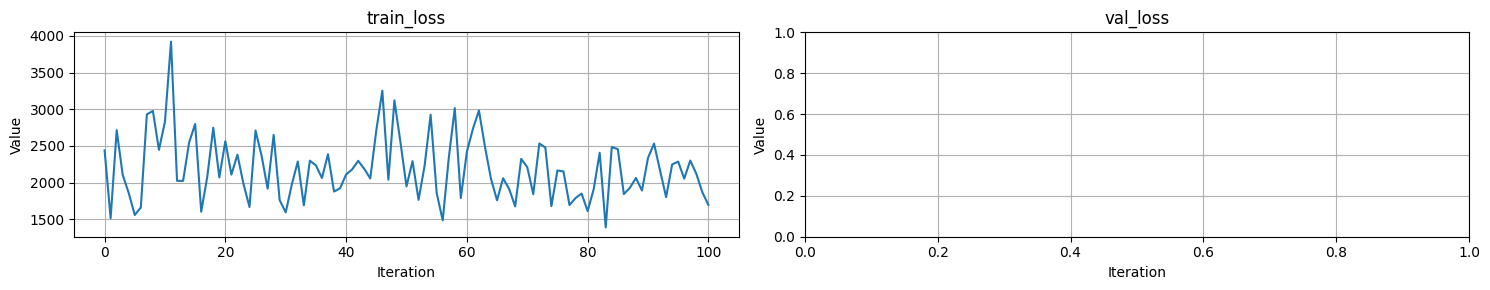

ValueError: cannot reshape array of size 576 into shape (26)

In [41]:
mlp_mae = MLP_MAE(window_size, num_features, 64, 3)

train_mae(mlp_mae, train_loader, val_loader, 400, device)